In [1]:
import cv2
import numpy as np
import time
from matplotlib import pyplot as plt

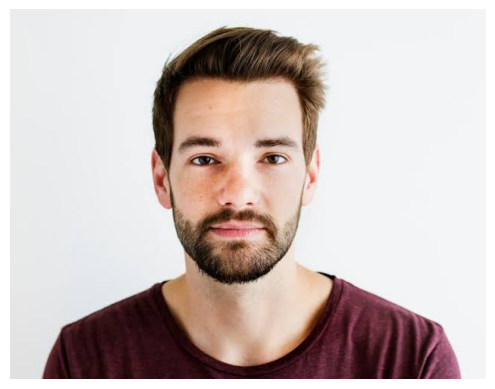

In [2]:
image = cv2.imread('images.jpg')

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.axis('off')
plt.show()

In [3]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

faces = face_cascade.detectMultiScale(
    image_rgb,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

for (x, y, w, h) in faces:
    cv2.rectangle(image, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv2.putText(image, "Face", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)

cv2.imshow("Detected Faces", image)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [4]:
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Не удалось открыть камеру")
    exit()

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

start_time = time.time()
DURATION = 15

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 5)
    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)

    cv2.imshow('Webcam', frame)

    elapsed = time.time() - start_time
    if elapsed >= DURATION:
        print(f"Время истекло ({DURATION} сек), закрываем окно.")
        break

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Время истекло (15 сек), закрываем окно.


In [5]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from skimage.feature import hog
from tensorflow import keras
from tensorflow.keras import layers
from skimage import exposure
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report
import torchvision.datasets as datasets
import seaborn as sns
from sklearn.manifold import TSNE
import random

In [6]:
train_dataset = datasets.GTSRB(
    root='./data',
    split='train',
    download=True
)

test_dataset = datasets.GTSRB(
    root='./data',
    split='test',
    download=True
)

In [7]:
def dataset_to_arrays(dataset):
    images, labels = [], []
    for img, label in dataset:
        img_resized = img.resize((128, 128))
        images.append(np.array(img_resized))
        labels.append(label)
    return np.array(images), np.array(labels)

X_train_raw, y_train = dataset_to_arrays(train_dataset)
X_test_raw, y_test = dataset_to_arrays(test_dataset)

print(f"Размер обучающей выборки: {X_train_raw.shape}")
print(f"Размер тестовой выборки: {X_test_raw.shape}")

Размер обучающей выборки: (26640, 128, 128, 3)
Размер тестовой выборки: (12630, 128, 128, 3)


In [8]:
def extract_hog_features(images):
    features = []
    for img in images:
        if img.ndim == 3:
            img_gray = np.dot(img[...,:3], [0.2989, 0.5870, 0.1140])
        else:
            img_gray = img

        fd = hog(
            img_gray,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            visualize=False
        )
        features.append(fd)
    return np.array(features)

X_train_hog = extract_hog_features(X_train_raw)
X_test_hog = extract_hog_features(X_test_raw)

print(f"Размерность одного HOG-вектора: {X_train_hog.shape[1]}")

Размерность одного HOG-вектора: 8100


In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_hog)
X_test_scaled = scaler.transform(X_test_hog)

In [10]:
mlp = MLPClassifier(
    hidden_layer_sizes=(512, 256),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    batch_size=256,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=50,
    verbose=True,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

print("\nОценка модели на тестовой выборке...")
y_pred = mlp.predict(X_test_scaled)

print(classification_report(y_test, y_pred, digits=4))

accuracy = np.mean(y_pred == y_test)
print(f"Общая точность на тесте: {accuracy:.4f}")

Iteration 1, loss = 0.33900912
Iteration 2, loss = 0.01095495
Iteration 3, loss = 0.00236968
Iteration 4, loss = 0.00068635
Iteration 5, loss = 0.00047242
Iteration 6, loss = 0.00043711
Iteration 7, loss = 0.00041680
Iteration 8, loss = 0.00040265
Iteration 9, loss = 0.00039210
Iteration 10, loss = 0.00038383
Iteration 11, loss = 0.00037725
Iteration 12, loss = 0.00037188
Iteration 13, loss = 0.00036741
Iteration 14, loss = 0.00036361
Iteration 15, loss = 0.00036039
Iteration 16, loss = 0.00035764
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.

Оценка модели на тестовой выборке...
              precision    recall  f1-score   support

           0     0.9412    0.8000    0.8649        60
           1     0.9224    0.8917    0.9068       720
           2     0.8796    0.9547    0.9156       750
           3     0.9177    0.8422    0.8783       450
           4     0.9613    0.9409    0.9510       660
           5     0.8153    0.8968    0.8541 

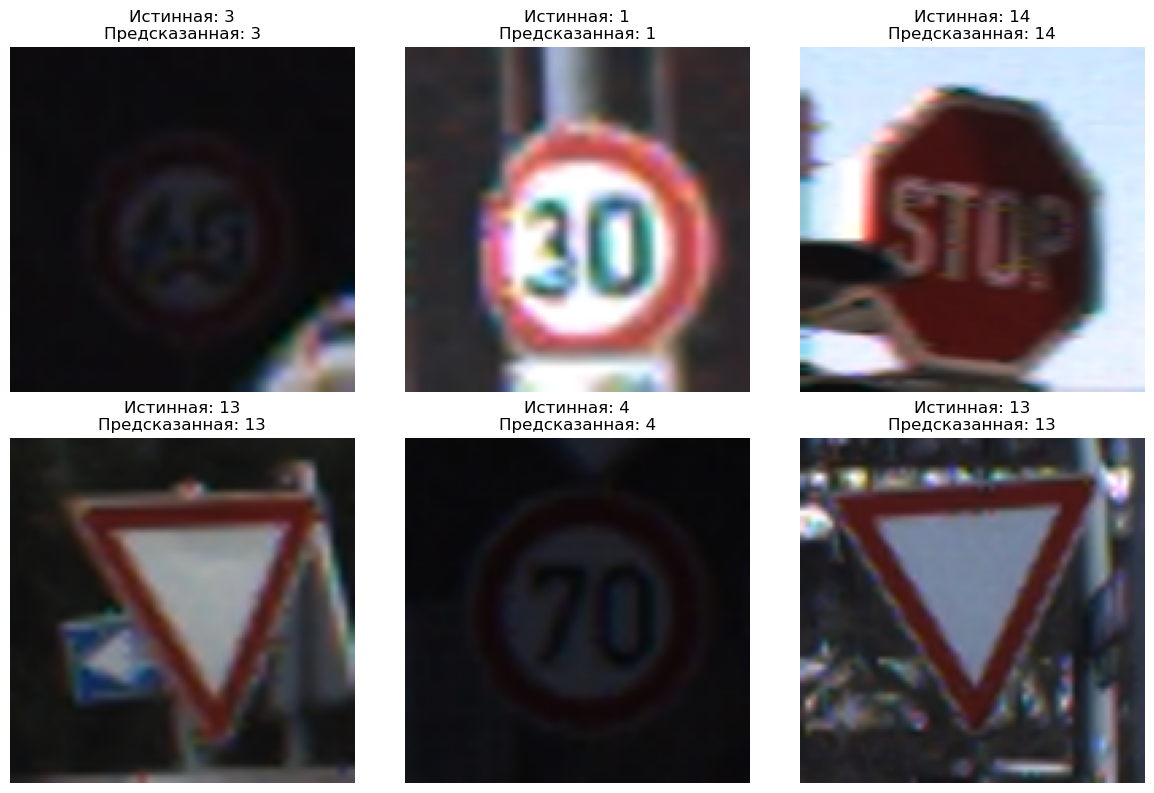

In [11]:
def show_random_predictions(X_raw, y_true, y_pred, num_samples=6):
    indices = random.sample(range(len(X_raw)), num_samples)
    plt.figure(figsize=(12, 8))
    for i, idx in enumerate(indices):
        plt.subplot(2, 3, i+1)
        img = X_raw[idx]
        if img.ndim == 3:
            plt.imshow(img)
        else:
            plt.imshow(img, cmap='gray')
        plt.title(f"Истинная: {y_true[idx]}\nПредсказанная: {y_pred[idx]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

y_pred = mlp.predict(X_test_scaled)

show_random_predictions(X_test_raw, y_test, y_pred, num_samples=6)

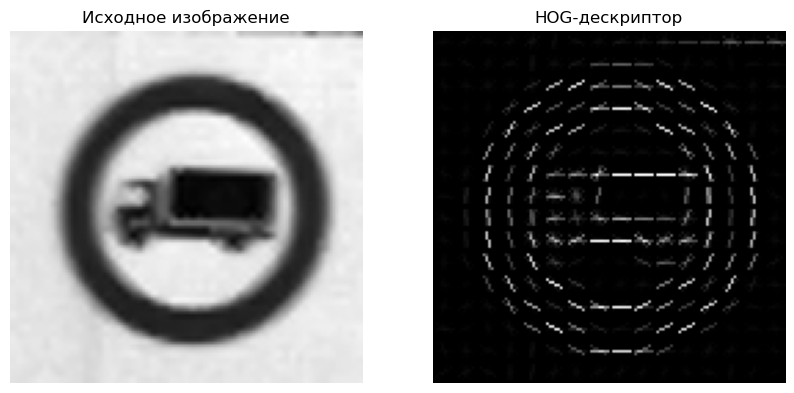

In [12]:
def show_hog_descriptor(img, hog_features):
    if img.ndim == 3:
        img_gray = np.dot(img[...,:3], [0.2989, 0.5870, 0.1140])
    else:
        img_gray = img

    fd, hog_image = hog(
        img_gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=True
    )

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    ax1.imshow(img_gray, cmap='gray')
    ax1.set_title('Исходное изображение')
    ax1.axis('off')

    ax2.imshow(hog_image, cmap='gray')
    ax2.set_title('HOG-дескриптор')
    ax2.axis('off')
    plt.show()

sample_img = X_test_raw[0]
sample_hog = X_test_hog[0]
show_hog_descriptor(sample_img, sample_hog)

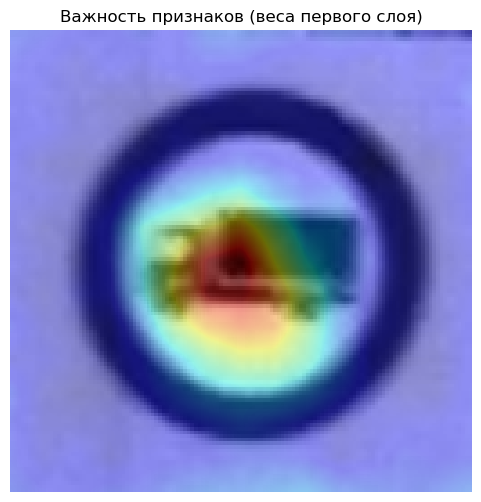

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

def visualize_feature_importance(mlp, sample_image, hog_features, 
                                 cells_per_block=2, orientations=9):
    weights = mlp.coefs_[0]
    importance = np.mean(np.abs(weights), axis=1)

    n_features = importance.shape[0]

    block_cells = cells_per_block * cells_per_block * orientations
    n_blocks = int(np.sqrt(n_features / block_cells))

    expected_size = n_blocks * n_blocks * block_cells
    if expected_size != n_features:
        print(f"Предупреждение: ожидаемый размер {expected_size}, фактический {n_features}. "
              "Возможно, использованы другие параметры HOG.")
        for nb in range(1, 50):
            if nb * nb * block_cells == n_features:
                n_blocks = nb
                break
        else:
            raise ValueError("Не удалось определить количество блоков. Проверьте параметры HOG.")

    importance_reshaped = importance.reshape(n_blocks, n_blocks, 
                                             cells_per_block, cells_per_block, 
                                             orientations)
    importance_map = np.sum(importance_reshaped, axis=(2, 3, 4))

    if sample_image.ndim == 3:
        img_gray = np.dot(sample_image[..., :3], [0.2989, 0.5870, 0.1140])
    else:
        img_gray = sample_image

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(img_gray, cmap='gray')

    h, w = img_gray.shape
    zoom_factor_y = h / n_blocks
    zoom_factor_x = w / n_blocks
    importance_upscaled = zoom(importance_map, (zoom_factor_y, zoom_factor_x), order=1)
    importance_upscaled = np.maximum(importance_upscaled, 0)

    ax.imshow(importance_upscaled, cmap='jet', alpha=0.4, interpolation='bilinear')
    ax.set_title('Важность признаков (веса первого слоя)')
    ax.axis('off')
    plt.show()

visualize_feature_importance(mlp, X_test_raw[0], X_test_hog[0], 
                             cells_per_block=2, orientations=9)

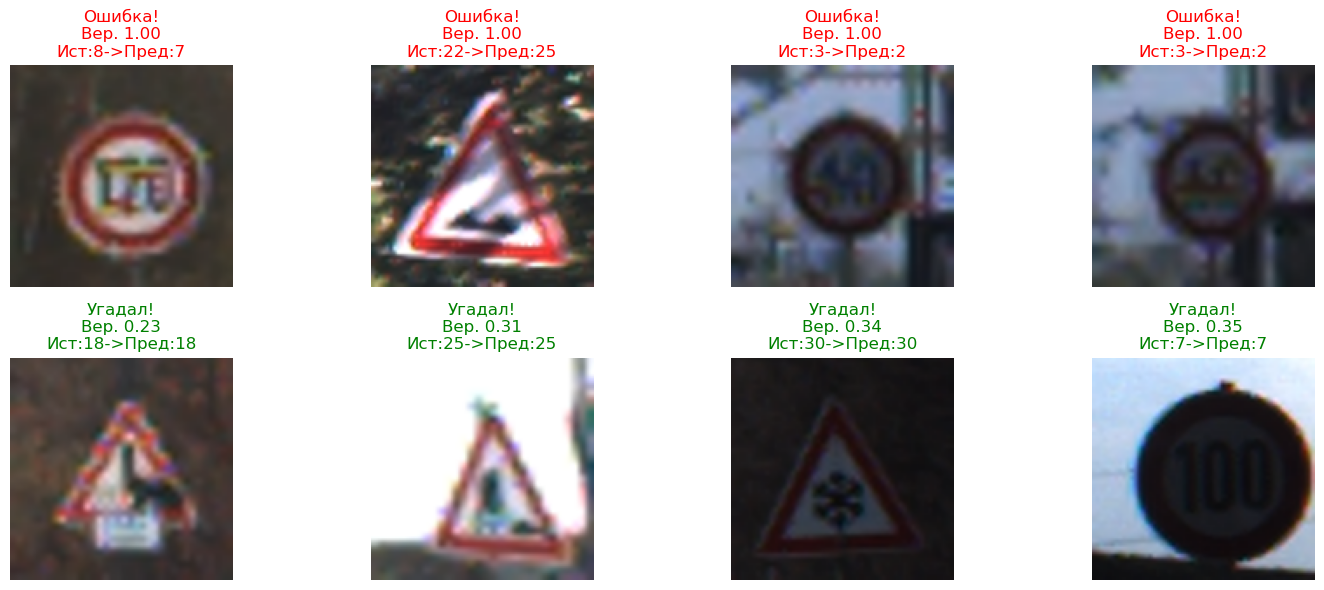

In [ ]:
def show_extreme_predictions(mlp, X_raw, X_scaled, y_true, n_samples=4):
    probs = mlp.predict_proba(X_scaled)
    max_probs = np.max(probs, axis=1)
    preds = np.argmax(probs, axis=1)

    wrong_mask = (preds != y_true)
    wrong_conf = max_probs * wrong_mask
    wrong_conf[~wrong_mask] = -1 
    top_wrong_idx = np.argsort(-wrong_conf)[:n_samples]

    correct_mask = (preds == y_true)
    correct_conf = max_probs * correct_mask
    correct_conf[~correct_mask] = 2
    top_uncertain_idx = np.argsort(correct_conf)[:n_samples]

    fig, axes = plt.subplots(2, n_samples, figsize=(15, 6))
    for i, idx in enumerate(top_wrong_idx):
        axes[0, i].imshow(X_raw[idx])
        axes[0, i].set_title(f'Ошибка!\nВер. {max_probs[idx]:.2f}\nИст:{y_true[idx]}->Пред:{preds[idx]}', color='red')
        axes[0, i].axis('off')
    
    for i, idx in enumerate(top_uncertain_idx):
        axes[1, i].imshow(X_raw[idx])
        axes[1, i].set_title(f'Угадал!\nВер. {max_probs[idx]:.2f}\nИст:{y_true[idx]}->Пред:{preds[idx]}', color='green')
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()

show_extreme_predictions(mlp, X_test_raw, X_test_scaled, y_test, n_samples=4)

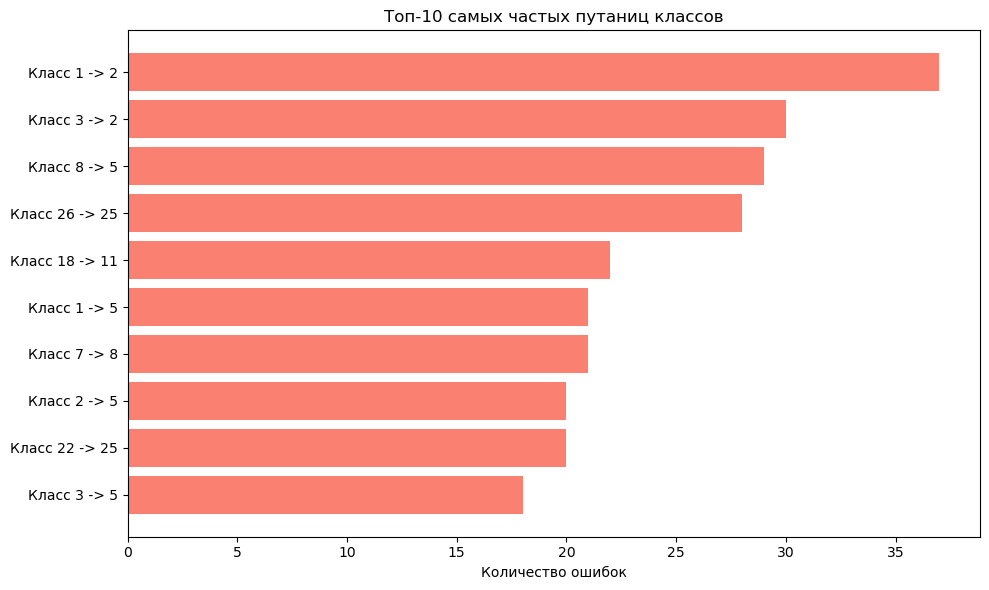

In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

def plot_top_confusions(y_true, y_pred, top_k=10):
    cm = confusion_matrix(y_true, y_pred)
    np.fill_diagonal(cm, 0)

    confusions = []
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if cm[i, j] > 0:
                confusions.append((i, j, cm[i, j]))

    confusions.sort(key=lambda x: -x[2])
    top_conf = confusions[:top_k]

    labels = [f"Класс {i} -> {j}" for i, j, _ in top_conf]
    values = [v for _, _, v in top_conf]
    
    plt.figure(figsize=(10, 6))
    plt.barh(labels, values, color='salmon')
    plt.xlabel('Количество ошибок')
    plt.title(f'Топ-{top_k} самых частых путаниц классов')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

plot_top_confusions(y_test, y_pred, top_k=10)

c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_percept

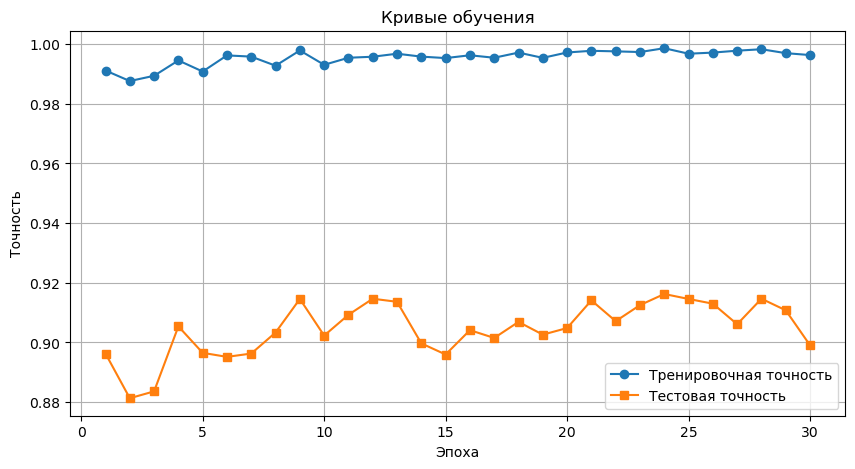

In [ ]:
def plot_learning_curves(X_train, y_train, X_test, y_test):
    mlp_curve = MLPClassifier(
        hidden_layer_sizes=(512, 256),
        activation='relu',
        max_iter=1,
        warm_start=True,
        random_state=42,
        verbose=False
    )
    
    train_scores = []
    test_scores = []
    n_epochs = 30
    
    for epoch in range(n_epochs):
        mlp_curve.fit(X_train, y_train)
        train_scores.append(mlp_curve.score(X_train, y_train))
        test_scores.append(mlp_curve.score(X_test, y_test))
    
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, n_epochs+1), train_scores, label='Тренировочная точность', marker='o')
    plt.plot(range(1, n_epochs+1), test_scores, label='Тестовая точность', marker='s')
    plt.xlabel('Эпоха')
    plt.ylabel('Точность')
    plt.title('Кривые обучения')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_learning_curves(X_train_scaled, y_train, X_test_scaled, y_test)